## Surrogate Testing on MMCows cow movement data

Many time series analyses tools assume that the data comes from a nonlinear, deterministic system. The naive solution to determine if this is the case for a signal is to take a look at our signal manually. A simple linear or sinusoidal signal stands out easily from a complex and structured one, but that might not be the case when the signal is noisy, contains linear correlations or non-stationarities. How can we actually statistically quantify this? One way we explore in this blog post is using surrogate testing. 

With surrogate testing we generate surrogate signals and compare them with our original. These surrogates preserve certain properties of the signal such as a mean and variance while destroying the nonlinear structure. Comparing these signals allows us to verify if the original data was generated by a linear, deterministic process or not. In this blog post, we'll go over two methods of doing surrogate testing (Random permutation surrogates and Amplitude Adjusted Fourier Transform), and can compare the surrogates with our original using sample entropy measurements.

### Importing necessary functions

In [ ]:
%pip install scipy numpy hampel polars matplotlib
import os, glob
import polars as pl
import numpy as np
from scipy.fft import fft, ifft
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt
from hampel import hampel
os.makedirs('surrogate_testing_results', exist_ok=True)


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Loading in and preprocessing the data

After loading in the data, we first filter out irregular sensor readings using a hampel filter, concatenate all our data into a single time series, normalize the signal and downsample it to reduce computational load. 

In [117]:
def normalize(signal):
    m = np.mean(signal)
    sd = np.std(signal)
    return (signal - m) / sd

def load_cow_coordinates_file(file):
    df = pl.read_csv(file)
    
    # Cast to Float64
    df = df.with_columns([
        pl.col("timestamp").cast(pl.Float64),
        pl.col("coord_x_cm").cast(pl.Float64),
        pl.col("coord_y_cm").cast(pl.Float64),
        pl.col("coord_z_cm").cast(pl.Float64),
    ])
    
    # Drop NaN
    df = df.filter(
        ~(pl.col("coord_x_cm").is_nan() |
          pl.col("coord_y_cm").is_nan() |
          pl.col("coord_z_cm").is_nan())
    )

    # Drop NaN
    df = df.filter(pl.col("timestamp").is_not_null() & ~pl.col("timestamp").is_nan())
    
    if df.height == 0:
        return np.array([]), np.empty((0, 3), dtype=np.float64)
    
    timestamp = df["timestamp"].to_numpy()
    x = df["coord_x_cm"].to_numpy()  # Normalize to make the signal stationary.
    y = df["coord_y_cm"].to_numpy()
    z = df["coord_z_cm"].to_numpy()

    # After extracting x, y, z as numpy arrays
    x = hampel(x, window_size=8, n_sigma=1.5).filtered_data
    y = hampel(y, window_size=8, n_sigma=1.5).filtered_data
    z = hampel(z, window_size=8, n_sigma=1.5).filtered_data
    points = np.column_stack((x, y, z)).astype(np.float64)
    return timestamp, points

def load_cow_coordinates_folder(folder, downsample_factor=1):
    csv_files = glob.glob(os.path.join(folder, "*.csv"))
    if not csv_files:
        return np.array([]), np.empty((0, 3))

    all_ts = []
    all_pts = []
    for f in csv_files:
        ts, pts = load_cow_coordinates_file(f)
        if pts.size == 0:
            continue
        all_ts.append(ts)
        all_pts.append(pts)

    if not all_ts:
        return np.array([]), np.empty((0, 3))

    # Concatenate all data
    combined_ts = np.concatenate(all_ts)
    combined_pts = np.concatenate(all_pts, axis=0)

    # Sort by timestamp to ensure correct temporal order
    sort_idx = np.argsort(combined_ts)
    sorted_ts = combined_ts[sort_idx]
    sorted_pts = combined_pts[sort_idx]

    # Normalize the whole concatenated signal per axis
    sorted_pts[:, 0] = normalize(sorted_pts[:, 0])
    sorted_pts[:, 1] = normalize(sorted_pts[:, 1])
    sorted_pts[:, 2] = normalize(sorted_pts[:, 2])

    # Downsample (take every 'downsample_factor' point)
    if downsample_factor > 1:
        sorted_ts = sorted_ts[::downsample_factor]
        sorted_pts = sorted_pts[::downsample_factor]

    return sorted_ts, sorted_pts

### Functions to display the data

To visualize our data, we have two functions, one that plots the XYZ location over time and one to plot individual signals. We can use the latter function to visually inspect our original signals and compare them with our surrogates.

In [118]:
def display_cow_3d(cow_3d_data, start_idx=0, segment_size=1000):
    timestamps, points = cow_3d_data
    
    if segment_size is not None:
        end_idx = min(start_idx + segment_size, len(timestamps))
    else:
        end_idx = len(timestamps)
    
    # Extract the segment
    ts_seg = timestamps[start_idx:end_idx]
    pts_seg = points[start_idx:end_idx]
    
    x = pts_seg[:, 0]
    y = pts_seg[:, 1]
    z = pts_seg[:, 2]
    
    print(f"Displaying {len(ts_seg)} points (indices {start_idx} to {end_idx-1})")
        
    fig = plt.figure(figsize=(12, 5))
    
    # ---- 3D Trajectory (line) ----
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(x, y, z, 'b-', linewidth=0.8, alpha=0.8)
    ax1.set_xlabel('X (cm)')
    ax1.set_ylabel('Y (cm)')
    ax1.set_zlabel('Z (cm)')
    ax1.set_title(f'3D Trajectory (segment: {len(ts_seg)} points)')
    
    # ---- Top‑down View (line) ----
    ax2 = fig.add_subplot(122)
    ax2.plot(x, y, 'b-', linewidth=0.8, alpha=0.8)
    ax2.set_xlabel('X (cm)')
    ax2.set_ylabel('Y (cm)')
    ax2.set_title('Top‑down View (X‑Y)')
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig("surrogate_testing_results/cow_plot.png")
    plt.show()

def plot_signal(timestamps, data, x_label="Time (s)", y_label="Value", title="Title", scale_time=True):
    if scale_time:
        time_axis = timestamps - timestamps[0]
        x_label = "Elapsed time (s)"
    else:
        time_axis = timestamps
    
    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, data, linewidth=1)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"surrogate_testing_results/{title}.png")
    plt.show()

### Surrogate testing functions

The following codeblocks contain the most important functions for us to generate the surrogates and compare them. We start off with the easiest method: The random permutation surrogate. This function takes the original time series and outputs random permutations of the original signal, simply the same signal with the values shuffled around. If we generated a surrogate for a signal, it would destroy all temporal order and look random while keeping the same mean and variance. This can be used to tests the null hypothesis that the data are independent and identically distributed.

In [119]:
def random_permutation_surrogate(x, n_samples=1):
    x = np.array(x)
    n = len(x)
    surrogates = []
    
    for _ in range(n_samples):
        perm = np.random.permutation(n)
        surrogates.append(x[perm])
    
    return np.array(surrogates).T

The next surrogate function is the Amplitude Adjusted Fourier Transform (AAFT). It is more complex and powerful, allowing us to keep linear relations intact while destroying just the nonlinear structure. It uses the Fourier transform to decompose the signal into a set of frequencies and phases, and instead of randomizing the signal values like with the earlier method, it randomizes the phases of the frequencies. These are then reconstructed into a surrogate signal of the original. Because the phase randomization of non-Gaussian data creates artifacts, it has to be preprocessed into a gaussian distributed form before the Fourier transform is applied, and transformed back after the signal reconstruction. 

In [120]:
def aaft_surrogate(x, n_samples=1):
    x = np.array(x)
    n = len(x)
    surrogates = []
    
    for _ in range(n_samples):
        # Step 1: Create Gaussian data with same rank structure
        ranks = np.argsort(np.argsort(x))
        gaussian = np.random.normal(size=n)
        sorted_gaussian = np.sort(gaussian)[ranks]
        
        # Step 2: Randomize phases in Fourier domain
        fft_coeffs = fft(sorted_gaussian)
        phases = np.angle(fft_coeffs)
        amplitudes = np.abs(fft_coeffs)
        
        # Randomize phases (keep first phase at 0 for real output)
        random_phases = np.random.uniform(0, 2*np.pi, n//2 - 1)
        new_phases = np.zeros(n)
        new_phases[1:n//2] = random_phases
        new_phases[n//2+1:] = -random_phases[::-1]  # Conjugate symmetry
        
        # Reconstruct Fourier coefficients
        new_fft = amplitudes * np.exp(1j * new_phases)
        if n % 2 == 0:
            new_fft[n//2] = amplitudes[n//2]  # Nyquist frequency is real
        
        # Step 3: Transform back and rescale amplitudes
        surrogate_gaussian = np.real(ifft(new_fft))
        
        # Step 4: Rescale to original amplitude distribution
        sorted_x = np.sort(x)
        ranks_surrogate = np.argsort(np.argsort(surrogate_gaussian))
        surrogate = sorted_x[ranks_surrogate]
        
        surrogates.append(surrogate)
    
    return np.array(surrogates).T  # Transpose to match R structure


To see how our surrogates compare to the original signals, we calculate their sample entropy. In essence, this measures how often short patterns in the signal repeat. A low sample entropy indicates a highly predictable signal, while a higher value indicates a less predictable signal. It works by constructing time delayed embeddings (see Taken's embedding theorem) from the signal and calculating the distance between all embeddings. The distance cutoff where we count embeddings as matching is in this case set as a default to 0.2 times the standard deviation of the signal. We check how many embeddings are close with the original embedding, and with a larger one to see how much information is gained by adding another timepoint to it. We can then calculate the entropy from these two values.

In [121]:
# Calculates Sample Entropy of a time series. This function was rewritten based on the pracma::sample_entropy function in R. It was validated to give approximately the same results.
def sample_entropy(signal, edim=2, r=None, tau=1):
    signal = np.array(signal)
    
    # If 1D, wrap in 2D and remember to return scalar
    if signal.ndim == 1:
        signal = signal[:, np.newaxis]
        return_scalar = True
    else:
        return_scalar = False
    
    N, n_samples = signal.shape
    
    if r is None:
        r = 0.2 * np.std(signal, axis=0)
    else:
        r = np.broadcast_to(r, n_samples)
    
    def construct_templates(x, m, tau):
        templates = []
        for i in range(len(x) - (m - 1) * tau):
            template = x[i:i + m * tau:tau]
            templates.append(template)
        return np.array(templates)
    
    def count_matches(templates, r_tol):
        n = len(templates)
        counts = 0
        for i in range(n - 1):
            dists = np.max(np.abs(templates[i+1:] - templates[i]), axis=1)
            counts += np.sum(dists <= r_tol)
        return counts
    
    results = np.empty(n_samples)
    for col in range(n_samples):
        x = signal[:, col]
        r_tol = r[col] if np.ndim(r) > 0 else r
        
        templates_m = construct_templates(x, edim, tau)
        B = count_matches(templates_m, r_tol)
        
        templates_m1 = construct_templates(x, edim + 1, tau)
        A = count_matches(templates_m1, r_tol)
        
        # Avoid dividing by zero
        if B == 0 or A == 0:
            results[col] = np.inf
        else:
            results[col] = -np.log(A / B)
    
    if return_scalar:
        return float(results[0])
    return results.mean()

To do all the tests in one go and see the statistical significance of the results, we can use these simple helper functions that run all the tests and visualize the results for us.

In [ ]:
def surrogate_test_signal(timestamps, values, label, title):
    plot_signal(timestamps, values, y_label=label, title=title)
    rperm_values = random_permutation_surrogate(values, 20)
    plot_signal(timestamps, rperm_values, y_label=label, title=title + " - Random Permutation")
    fftperm_values = aaft_surrogate(values, n_samples=20)
    plot_signal(timestamps, fftperm_values, y_label=label, title=title + " - AAFT Random Permutation")
    r = 0.2*np.std(values)
    values_se = sample_entropy(values, edim=2, r=r, tau=1)
    rperm_values_se = sample_entropy(rperm_values, edim=2, r=r, tau=1)
    fft_values_se = sample_entropy(fftperm_values, edim=2, r=r, tau=1)

    # Return the sample entropy for the baseline, random permutation, aaft random permutation.
    return values_se, rperm_values_se, fft_values_se

### Running the surrogate tests on the X, Y and Z position of a cow over the course of two weeks.

First we load in the data using our earlier defined functions, and display the 3D trajectory of the cow.

Displaying 1000 points (indices 0 to 999)


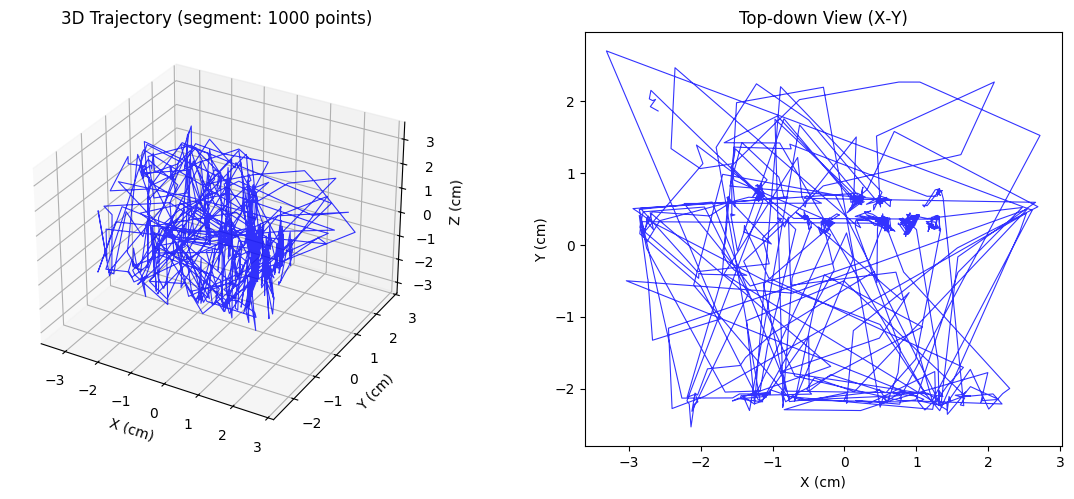

In [ ]:
cow_3d_folder = "../data/sensor_data/main_data/uwb/T01/"
cow_3d_data = load_cow_coordinates_folder(cow_3d_folder, downsample_factor=10)

display_cow_3d(cow_3d_data)
timestamps = cow_3d_data[0]   # shape (N,)
points = cow_3d_data[1]       # shape (N, 3)

# Extract coordinates correctly
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]

Applying our surrogate testing function gives us three nice plots, the original cow's X position, the random permutation surrogate and AAFT surrogate of the original. We can clearly see structure in the original signal, while the random permutation is exactly that, random. Our AAFT signal is more interesting, while it does have more structure that the random permutation surrogate, it's significantly more distinct from our original.

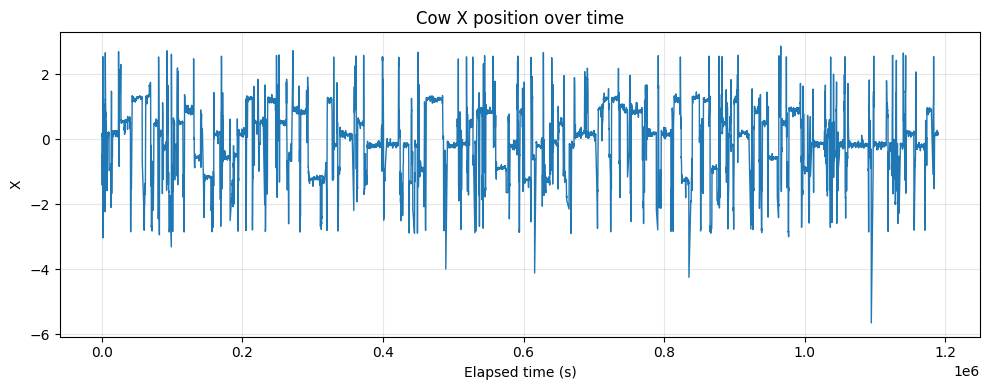

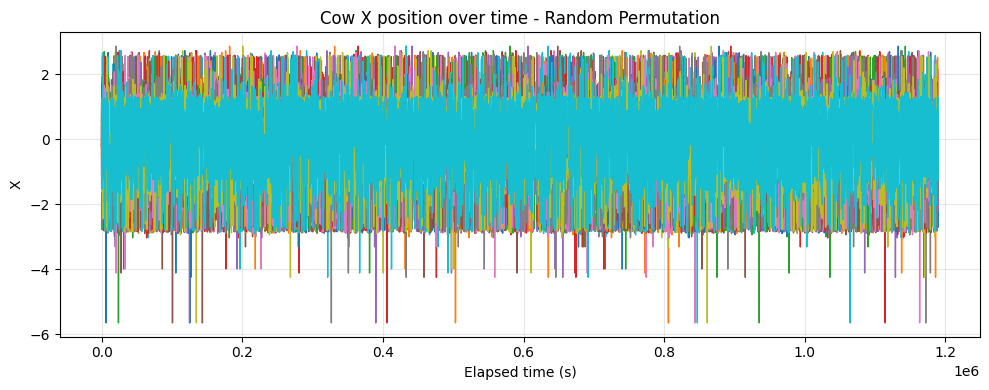

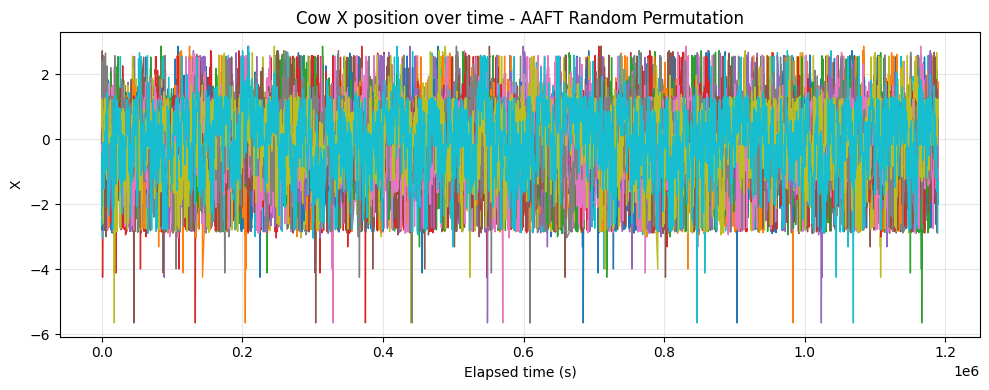

In [124]:
x_se, rperm_x_se, aaft_perm_x_se = surrogate_test_signal(timestamps, x, "X", "Cow X position over time")

We apply the same tests here to the Y position, and get similar results.

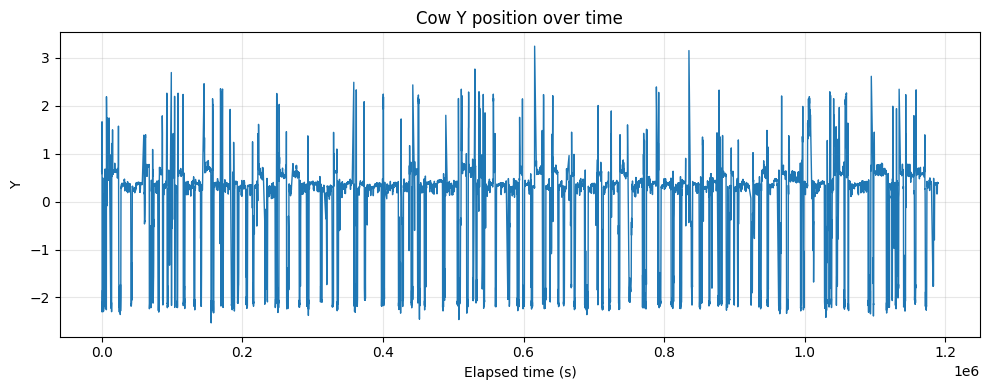

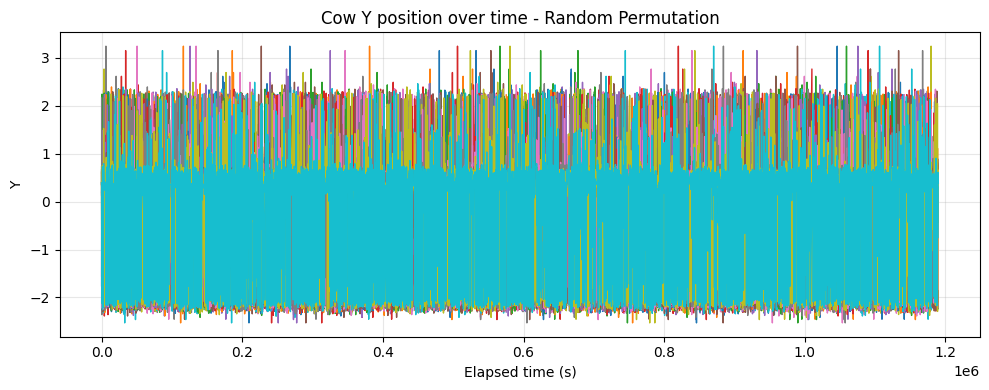

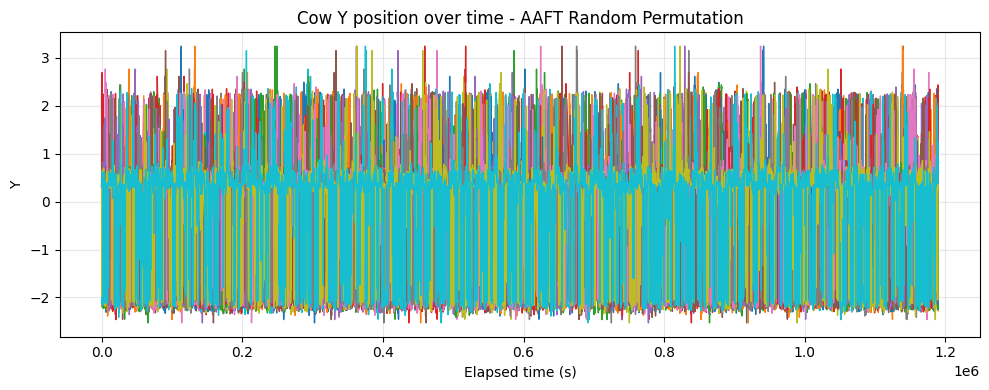

In [125]:
y_se, rperm_y_se, aaft_perm_y_se = surrogate_test_signal(timestamps, y, "Y", "Cow Y position over time")

Our cow's Z position looks more noisy, the random permutation surrogates are still noisier but harder to distinguish from the original, this is even more the case for the AAFT surrogate. Still, later on we'll see that the differences between the original and surrogates are statistically significant.

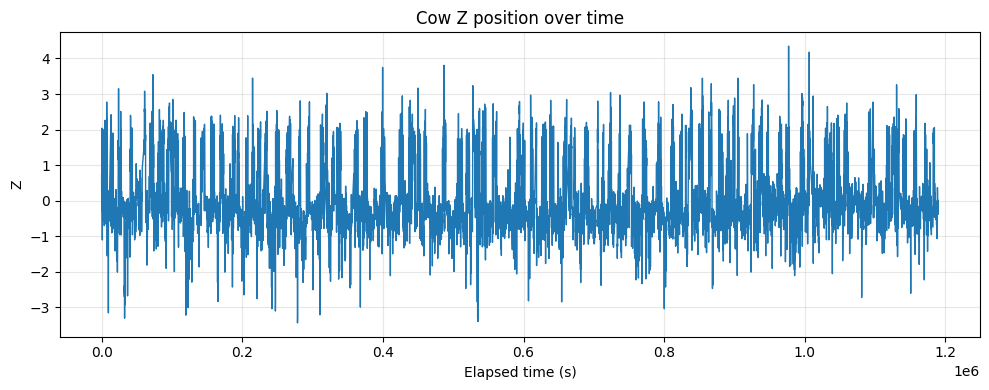

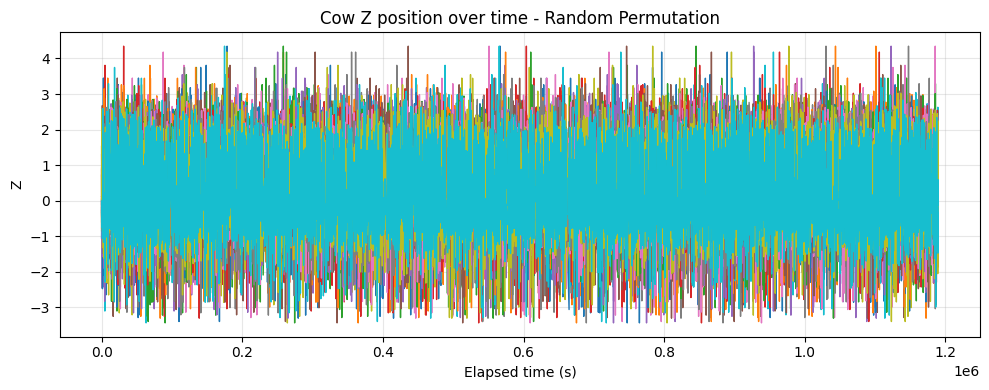

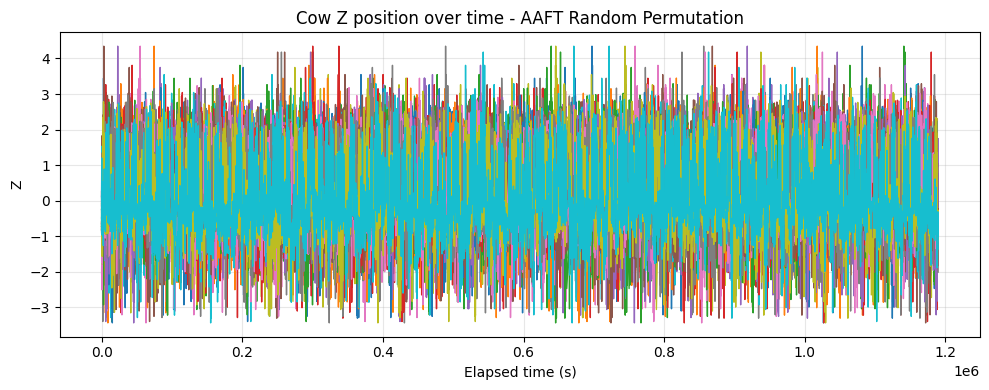

In [126]:
z_se, rperm_z_se, aaft_perm_z_se = surrogate_test_signal(timestamps, z, "Z", "Cow Z position over time")

Finally we print our sample entropy measurements from the original and the surrogates. They show large differences between the original X and Y and its surrogates. This is expected, as cows walk in directed bouts (to the feeder, to the resting area, pacing). They are structured, deterministic movement patterns. Linear noise cannot capture the persistence and turning behavior.

The Z axis is different, we see it being relatively close to the surrogates, though still more regular. This could be explained as the head movement being predicted by singular events, like eating or laying down, which is much less predictable.

In [127]:
print(f"{'Axis':<6} {'Random Surrogate':<20} {'AAFT Surrogate':<20} {'Original':<15}")
print("-" * 85)
print(f"{'X':<6} {rperm_x_se:<20.6f} {aaft_perm_x_se:<20.6f} {x_se:<15.6f}")
print(f"{'Y':<6} {rperm_y_se:<20.6f} {aaft_perm_y_se:<20.6f} {y_se:<15.6f}")
print(f"{'Z':<6} {rperm_z_se:<20.6f} {aaft_perm_z_se:<20.6f} {z_se:<15.6f}")

Axis   Random Surrogate     AAFT Surrogate       Original       
-------------------------------------------------------------------------------------
X      2.113205             1.390704             0.158920       
Y      0.996802             0.556571             0.136501       
Z      1.845578             1.582326             1.238371       
